In [20]:
# Bloco 1 - Setup
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibit_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibit_semantic_segmentation/'
# project_path = r'C:\Users\Renato\Documents\GitHub\pucpr_pibit_semantic_segmentation'
sys.path.append(os.path.abspath(project_path))

from core.validation import get_valid_image_number
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import cv2 as cv
import numpy as np

# Importando as definições de cores HSV
from core.colors import class_parameters

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
numpy_folder: str = os.getenv("NUMPY_FOLDER")

# Define numpy file path
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")
numpy_file_path: str = os.path.join(numpy_folder, f"{img_number}.npy")

# Load numpy file
numpy_file = np.load(numpy_file_path)

# Load mask for comparison
bgr_img = cv.imread(mask_path, 1)
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)

In [21]:
def reconstruct_image_hsv(npy_file: str):
    """
    Reconstrói a imagem a partir do arquivo numpy utilizando os valores HSV exatos 
    usados para extrair as classes originalmente.
    
    Args:
        npy_file (str): Caminho para o arquivo numpy com as máscaras
        
    Returns:
        ndarray: Imagem reconstruída em formato RGB
    """
    combined_mask = np.load(npy_file)
    h, w, num_classes = combined_mask.shape
    
    # Criar uma imagem HSV vazia (preto)
    reconstructed_hsv = np.zeros((h, w, 3), dtype=np.uint8)
    
    # Definir os valores HSV exatos para todas as classes
    # Valores específicos para as classes circulares
    exact_hsv_values = {
        0: None,  # Usar valores padrão do class_parameters
        1: None,  # Usar valores padrão do class_parameters
        2: [95, 150, 187],  # Crutch (circular)
        3: None,  # Usar valores padrão do class_parameters
        4: None,  # Usar valores padrão do class_parameters
        5: None,  # Usar valores padrão do class_parameters
        6: None,  # Usar valores padrão do class_parameters
        7: None,  # Usar valores padrão do class_parameters
        8: None,  # Usar valores padrão do class_parameters
        9: None,  # Usar valores padrão do class_parameters
        10: [0, 255, 255],  # Humans (circular)
        11: None,  # Usar valores padrão do class_parameters
        12: None,  # Usar valores padrão do class_parameters
        13: None,  # Usar valores padrão do class_parameters
        14: None,  # Usar valores padrão do class_parameters
        15: None,  # Usar valores padrão do class_parameters
        16: None,  # Usar valores padrão do class_parameters
        17: [11, 150, 187],  # Street Light Pole (circular)
        18: None,  # Usar valores padrão do class_parameters
        19: None,  # Usar valores padrão do class_parameters
        20: None,  # Usar valores padrão do class_parameters
        21: None,  # Usar valores padrão do class_parameters
    }
    
    # Para cada classe no arquivo numpy
    for i in range(num_classes):
        if i >= len(class_parameters):
            print(f"Aviso: Classe {i} não tem parâmetros definidos. Pulando.")
            continue
            
        mask = combined_mask[:, :, i]
        
        # Verificar se temos um valor HSV exato para esta classe
        if i in exact_hsv_values and exact_hsv_values[i] is not None:
            h_value, s_value, v_value = exact_hsv_values[i]
        else:
            # Usar os valores do class_parameters
            hsv_limits = class_parameters[i]["color_limits"]
            lower_hsv, upper_hsv = hsv_limits
            
            # Calcular o valor médio HSV para representação
            h_value = int((lower_hsv[0] + upper_hsv[0]) / 2)
            s_value = min(255, int((lower_hsv[1] + upper_hsv[1]) / 2) + 50)  # Aumentar saturação para melhor visualização
            v_value = min(255, int((lower_hsv[2] + upper_hsv[2]) / 2) + 30)  # Aumentar brilho para melhor visualização
        
        # Criar uma camada com a cor HSV desta classe
        color_layer = np.zeros_like(reconstructed_hsv)
        color_layer[mask == 255] = [h_value, s_value, v_value]
        
        # Combinar com a imagem reconstruída (priorizar valores não-zero)
        hsv_mask = mask > 0
        reconstructed_hsv[hsv_mask] = color_layer[hsv_mask]
    
    # Converter de HSV para RGB para visualização
    reconstructed_rgb = cv.cvtColor(reconstructed_hsv, cv.COLOR_HSV2RGB)
    
    return reconstructed_rgb

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

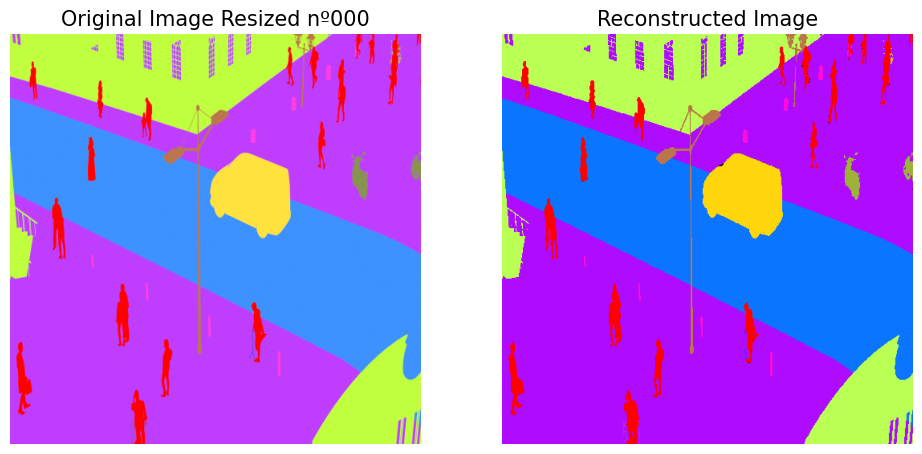

In [22]:
# Bloco 3 - Execução
recovered_image_hsv = reconstruct_image_hsv(numpy_file_path)

# Base Path para pasta de imagens recuperadas
recovered_img_folder: str = os.getenv("RECOVERED_IMG_FOLDER")

# Visualização e salvamento das imagens
plt.figure(figsize=[18, 6])

# Plotar imagem com cores HSV
plt.subplot(1, 3, 1)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image Resized nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(recovered_image_hsv)
plt.title("Reconstructed Image", fontdict={'fontsize': 15})
plt.axis('off')
